In [17]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [21]:
import numpy as np

# ── data: XOR problem ─────────────────────────────────────────────
# input pairs        [0,0] [0,1] [1,0] [1,1]
X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])   # shape (2, 4)

y = np.array([[0, 1, 1, 0]])   # shape (1, 4)

# ── activation functions ──────────────────────────────────────────
def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# ── initialize weights randomly ───────────────────────────────────
np.random.seed(42)   # so we get the same random numbers every run

W1 = np.random.randn(4, 2) * 0.1   # hidden layer  (4 neurons, 2 inputs)
b1 = np.zeros((4, 1))               # hidden biases

W2 = np.random.randn(1, 4) * 0.1   # output layer  (1 neuron, 4 inputs)
b2 = np.zeros((1, 1))               # output bias

learning_rate = 0.1

# ── training loop ─────────────────────────────────────────────────
for i in range(5000):

    # forward pass
    z1 = np.dot(W1, X) + b1       # hidden layer pre-activation
    a1 = relu(z1)                  # hidden layer output

    z2 = np.dot(W2, a1) + b2      # output layer pre-activation
    a2 = sigmoid(z2)               # final prediction

    # loss (average over all 4 training examples)
    loss = -np.mean(y * np.log(a2) + (1 - y) * np.log(1 - a2))

    # backprop — output layer
    dL_da2 = a2 - y                        # how wrong was the prediction
    dL_dW2 = np.dot(dL_da2, a1.T) / 4     # how much did W2 cause it
    dL_db2 = np.mean(dL_da2)              # how much did b2 cause it

    # backprop — hidden layer
    dL_da1 = np.dot(W2.T, dL_da2)                    # push error backwards
    dL_dz1 = dL_da1 * relu_derivative(z1)            # through relu
    dL_dW1 = np.dot(dL_dz1, X.T) / 4                # how much did W1 cause it
    dL_db1 = np.mean(dL_dz1, axis=1, keepdims=True)  # how much did b1 cause it

    # update weights — step downhill
    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1

    # print loss every 100 loops so we can watch it drop
    if i % 100 == 0:
        print(f"loop {i:4d}   loss: {loss:.4f}")

# ── final predictions ─────────────────────────────────────────────
print("\nafter training:")
print("predictions:", a2.round(2))
print("correct:    ", y)




loop    0   loss: 0.6932
loop  100   loss: 0.6922
loop  200   loss: 0.6878
loop  300   loss: 0.6721
loop  400   loss: 0.6274
loop  500   loss: 0.5570
loop  600   loss: 0.4947
loop  700   loss: 0.4064
loop  800   loss: 0.2941
loop  900   loss: 0.2034
loop 1000   loss: 0.1433
loop 1100   loss: 0.1050
loop 1200   loss: 0.0806
loop 1300   loss: 0.0641
loop 1400   loss: 0.0525
loop 1500   loss: 0.0441
loop 1600   loss: 0.0377
loop 1700   loss: 0.0329
loop 1800   loss: 0.0290
loop 1900   loss: 0.0259
loop 2000   loss: 0.0234
loop 2100   loss: 0.0212
loop 2200   loss: 0.0194
loop 2300   loss: 0.0179
loop 2400   loss: 0.0165
loop 2500   loss: 0.0154
loop 2600   loss: 0.0144
loop 2700   loss: 0.0135
loop 2800   loss: 0.0127
loop 2900   loss: 0.0119
loop 3000   loss: 0.0113
loop 3100   loss: 0.0107
loop 3200   loss: 0.0102
loop 3300   loss: 0.0097
loop 3400   loss: 0.0093
loop 3500   loss: 0.0088
loop 3600   loss: 0.0085
loop 3700   loss: 0.0081
loop 3800   loss: 0.0078
loop 3900   loss: 0.0075


Matplotlib is building the font cache; this may take a moment.


loop    0   loss: 0.6932
loop  500   loss: 0.5570
loop 1000   loss: 0.1433
loop 1500   loss: 0.0441
loop 2000   loss: 0.0234
loop 2500   loss: 0.0154
loop 3000   loss: 0.0113
loop 3500   loss: 0.0088
loop 4000   loss: 0.0072
loop 4500   loss: 0.0061

after training:
predictions: [[0.01 1.   1.   0.  ]]
correct:     [[0 1 1 0]]


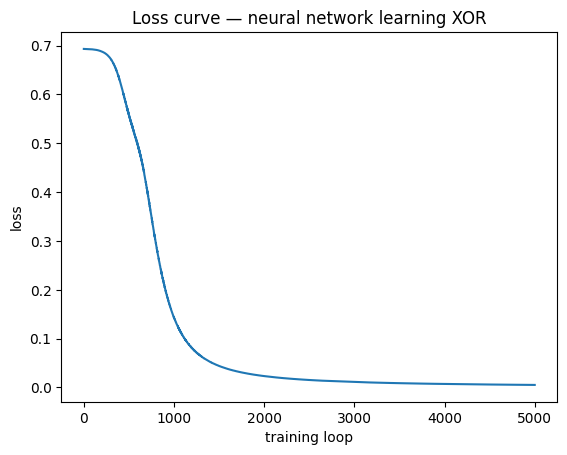


loss curve saved as loss_curve.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[0, 0, 1, 1],
              [0, 1, 0, 1]])

y = np.array([[0, 1, 1, 0]])

def relu(z):
    return np.maximum(0, z)

def relu_derivative(z):
    return (z > 0).astype(float)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

np.random.seed(42)

W1 = np.random.randn(4, 2) * 0.1
b1 = np.zeros((4, 1))
W2 = np.random.randn(1, 4) * 0.1
b2 = np.zeros((1, 1))

learning_rate = 0.1
loss_history = []   # new

for i in range(5000):   # new

    z1 = np.dot(W1, X) + b1
    a1 = relu(z1)
    z2 = np.dot(W2, a1) + b2
    a2 = sigmoid(z2)

    loss = -np.mean(y * np.log(a2) + (1 - y) * np.log(1 - a2))
    loss_history.append(loss)   # new

    dL_da2 = a2 - y
    dL_dW2 = np.dot(dL_da2, a1.T) / 4
    dL_db2 = np.mean(dL_da2)
    dL_da1 = np.dot(W2.T, dL_da2)
    dL_dz1 = dL_da1 * relu_derivative(z1)
    dL_dW1 = np.dot(dL_dz1, X.T) / 4
    dL_db1 = np.mean(dL_dz1, axis=1, keepdims=True)

    W2 -= learning_rate * dL_dW2
    b2 -= learning_rate * dL_db2
    W1 -= learning_rate * dL_dW1
    b1 -= learning_rate * dL_db1

    if i % 500 == 0:   # new
        print(f"loop {i:4d}   loss: {loss:.4f}")

print("\nafter training:")
print("predictions:", a2.round(2))
print("correct:    ", y)

# ── plot the loss curve ───────────────────────────────────────────
plt.plot(loss_history)
plt.title("Loss curve — neural network learning XOR")
plt.xlabel("training loop")
plt.ylabel("loss")
plt.savefig("loss_curve.png")   # saves as image file
plt.show()
print("\nloss curve saved as loss_curve.png")